<a href="https://www.kaggle.com/code/sonawanelalitsunil/h-m-product-dataset-scrapped?scriptVersionId=232981054" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/h-and-m-product-dataset/handm.csv


## Title: H&M Product Dataset (Scrapped)

### Description: A dataset of H&M products collected via web scraping, including item details like product name, category, price, and availability for analysis and trend insights.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/h-and-m-product-dataset/handm.csv')

In [3]:
df.head()

,Unnamed: 0,productId,productName,brandName,url,price,stockState,comingSoon,colorName,isOnline,colors,colorShades,newArrival,mainCatCode,details,materials
0,0,834333001,Derby Shoes,H&M,https://www2.hm.com/en_us/productpage.08343330...,49.99,Available,False,Black,True,272628,Charcoal,False,men_shoes_dressed,Derby shoes with open lacing at front. Canvas ...,COMPOSITION\nSole:Thermoplastic rubber 100%\nU...
1,1,1258600003,Pile-Lined Slippers,H&M,https://www2.hm.com/en_us/productpage.12586000...,24.99,Available,False,Black,True,272628,Charcoal,False,men_shoes_slippers,Slippers in napped fabric. Decorative seam at ...,COMPOSITION\nLining:Polyester 100%\nUpper:Poly...
2,2,1036812001,Derby Shoes,H&M,https://www2.hm.com/en_us/productpage.10368120...,56.99,Available,False,Black,True,272628,Charcoal,False,men_shoes_dressed,Derby shoes in soft faux suede with open lacin...,COMPOSITION\nLining and insole:Cotton 100%\nUp...
3,3,1112924002,Fleece-lined Slippers,H&M,https://www2.hm.com/en_us/productpage.11129240...,29.99,Available,False,Dark blue,True,393B47,Bright blue|Cobalt blue|Dark blue|Indigo|Navy ...,False,men_shoes_slippers,Slippers in woven fabric with a moccasin seam ...,COMPOSITION\nLining:Polyester 100%\nUpper:Poly...
4,4,1119476020,Sneakers,H&M,https://www2.hm.com/en_us/productpage.11194760...,29.99,Available,False,White,True,FFFFFF,NaN,False,men_shoes_sneakers,"Sneakers with a padded upper edge and tongue, ...",COMPOSITION\nLining:Polyester 100%\nUpper:Poly...


In [4]:
df.tail()

,Unnamed: 0,productId,productName,brandName,url,price,stockState,comingSoon,colorName,isOnline,colors,colorShades,newArrival,mainCatCode,details,materials
9672,9672,1199187014,Slim Straight High Jeans,H&M,https://www2.hm.com/en_us/productpage.11991870...,34.99,Available,False,Beige,True,BBAB92,Ecru|Taupe|Wheat,False,ladies_jeans_straight,"Straight-fit, 5-pocket jeans in cotton denim w...","COMPOSITION\nShell:Cotton 99%, Spandex 1%\nPoc..."
9673,9673,1198343002,Bootcut High Jeans,H&M,https://www2.hm.com/en_us/productpage.11983430...,39.99,Available,False,Light denim blue,True,79829D,Blue gray|Bright blue|Pastel blue|Royal blue,False,ladies_jeans_bootcut,"5-pocket, bootcut jeans in cotton denim with g...","COMPOSITION\nShell:Cotton 99%, Spandex 1%\nPad..."
9674,9674,1232588003,Lace Push-up Bra,H&M,https://www2.hm.com/en_us/productpage.12325880...,17.99,Available,False,Powder pink,True,CCC2C2,Coral|Dusty pink|Light pink|Salmon,False,ladies_lingerie_bras_padded,Push-up bra in lace. Adjustable shoulder strap...,"COMPOSITION\nFront:Polyamide 88%, Spandex 12%\..."
9675,9675,1208310002,2-pack Padded Soft-cup Cotton Bras,H&M,https://www2.hm.com/en_us/productpage.12083100...,24.99,Available,False,Beige/black,True,BEA894,Ecru|Taupe|Wheat,False,ladies_lingerie_bras_multipack,Soft-cup bras in cotton jersey. Adjustable sho...,"COMPOSITION\nShell:Cotton 95%, Spandex 5%\nLin..."
9676,9676,1227825002,Padded Balconette Bikini Top,H&M,https://www2.hm.com/en_us/productpage.12278250...,19.99,Available,False,Brown,True,745A43,NaN,False,ladies_swimwear_bikinisets_tops,"Lined balconette bikini top. Detachable, adjus...","COMPOSITION\nShell:Polyester 93%, Spandex 7%\n..."


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9677 entries, 0 to 9676
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   9677 non-null   int64  
 1   productId    9677 non-null   int64  
 2   productName  9677 non-null   object 
 3   brandName    9677 non-null   object 
 4   url          9677 non-null   object 
 5   price        9677 non-null   float64
 6   stockState   9677 non-null   object 
 7   comingSoon   9677 non-null   bool   
 8   colorName    9677 non-null   object 
 9   isOnline     9677 non-null   bool   
 10  colors       9677 non-null   object 
 11  colorShades  6511 non-null   object 
 12  newArrival   9677 non-null   bool   
 13  mainCatCode  9677 non-null   object 
 14  details      9676 non-null   object 
 15  materials    9518 non-null   object 
dtypes: bool(3), float64(1), int64(2), object(10)
memory usage: 1011.3+ KB


In [6]:
df.describe()

,Unnamed: 0,productId,price
count,9677.000000,9.677000e+03,9677.000000
mean,4838.000000,1.188702e+09,34.215088
std,2793.653611,1.206040e+08,28.262665
min,0.000000,1.077270e+08,3.990000
25%,2419.000000,1.198945e+09,18.990000
50%,4838.000000,1.230524e+09,29.990000
75%,7257.000000,1.244770e+09,39.990000
max,9676.000000,1.280785e+09,469.000000


In [7]:
df.isnull().sum()

Unnamed: 0        0
productId         0
productName       0
brandName         0
url               0
price             0
stockState        0
comingSoon        0
colorName         0
isOnline          0
colors            0
colorShades    3166
newArrival        0
mainCatCode       0
details           1
materials       159
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.shape

(9677, 16)

In [10]:
df.isnull().sum().sum()

3326

In [11]:
df.dtypes

Unnamed: 0       int64
productId        int64
productName     object
brandName       object
url             object
price          float64
stockState      object
comingSoon        bool
colorName       object
isOnline          bool
colors          object
colorShades     object
newArrival        bool
mainCatCode     object
details         object
materials       object
dtype: object

In [12]:
df.columns

Index(['Unnamed: 0', 'productId', 'productName', 'brandName', 'url', 'price',
       'stockState', 'comingSoon', 'colorName', 'isOnline', 'colors',
       'colorShades', 'newArrival', 'mainCatCode', 'details', 'materials'],
      dtype='object')

## Data visualizations

In [13]:
from wordcloud import WordCloud
from collections import Counter
import ast

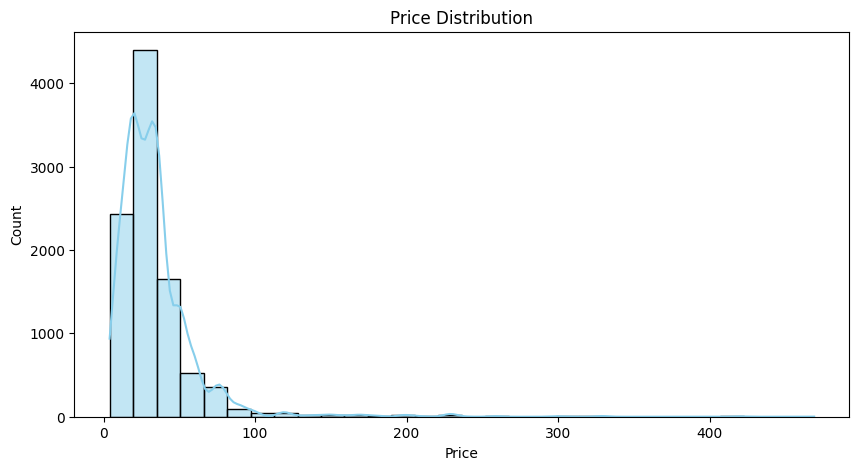

In [14]:
# 1. Product Price Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=30, kde=True, color='skyblue')
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()


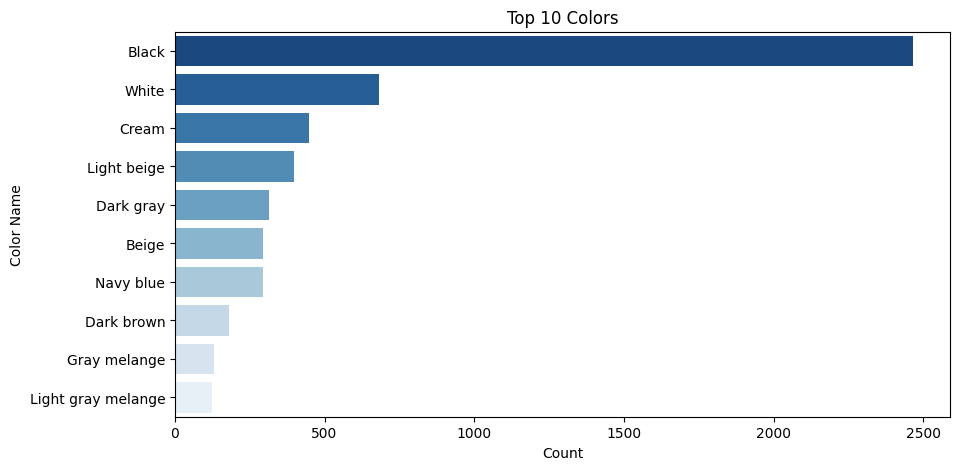

In [15]:
# 2. Top Colors
plt.figure(figsize=(10, 5))
top_colors = df['colorName'].value_counts().nlargest(10)
sns.barplot(x=top_colors.values, y=top_colors.index, palette='Blues_r')
plt.title('Top 10 Colors')
plt.xlabel('Count')
plt.ylabel('Color Name')
plt.show()


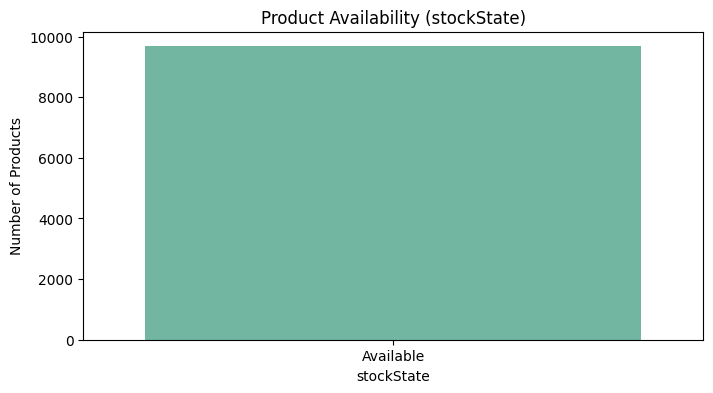

In [16]:
# 3. Product Availability Status
plt.figure(figsize=(8, 4))
avail_counts = df['stockState'].value_counts()
sns.barplot(x=avail_counts.index, y=avail_counts.values, palette='Set2')
plt.title('Product Availability (stockState)')
plt.ylabel('Number of Products')
plt.show()

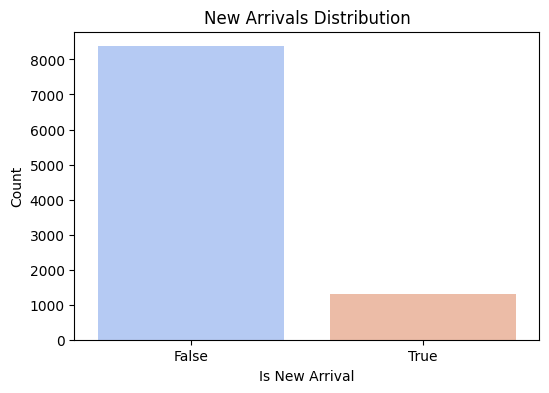

In [17]:
# 4. New Arrival Products
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='newArrival', palette='coolwarm')
plt.title('New Arrivals Distribution')
plt.xlabel('Is New Arrival')
plt.ylabel('Count')
plt.show()


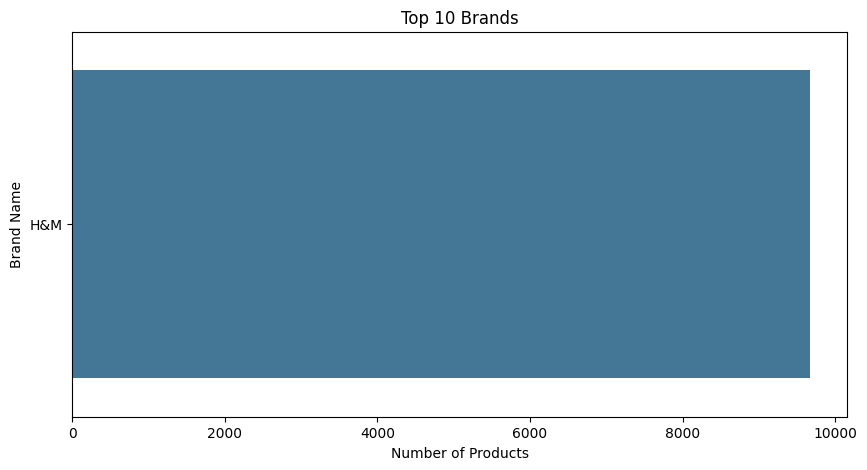

In [18]:
# 5. Top Brands
plt.figure(figsize=(10, 5))
top_brands = df['brandName'].value_counts().nlargest(10)
sns.barplot(x=top_brands.values, y=top_brands.index, palette='mako')
plt.title('Top 10 Brands')
plt.xlabel('Number of Products')
plt.ylabel('Brand Name')
plt.show()


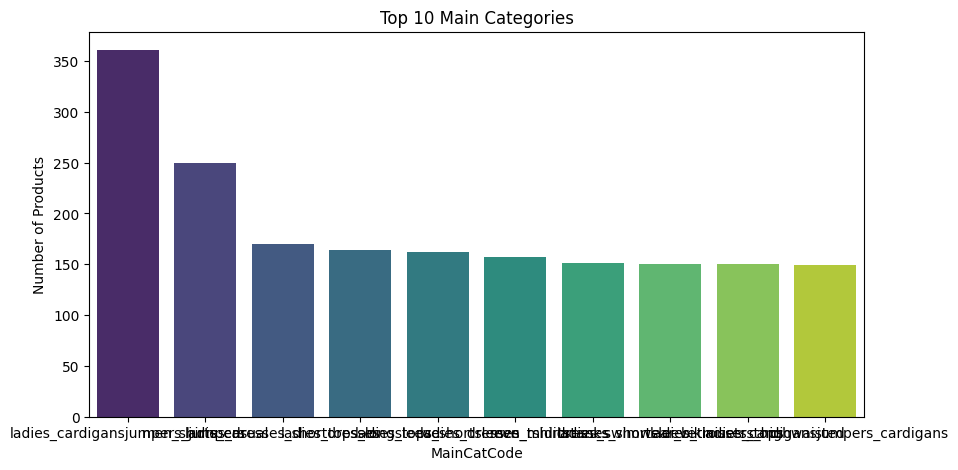

In [19]:
# 6. Main Category Code Distribution
plt.figure(figsize=(10, 5))
top_cats = df['mainCatCode'].value_counts().nlargest(10)
sns.barplot(x=top_cats.index.astype(str), y=top_cats.values, palette='viridis')
plt.title('Top 10 Main Categories')
plt.xlabel('MainCatCode')
plt.ylabel('Number of Products')
plt.show()


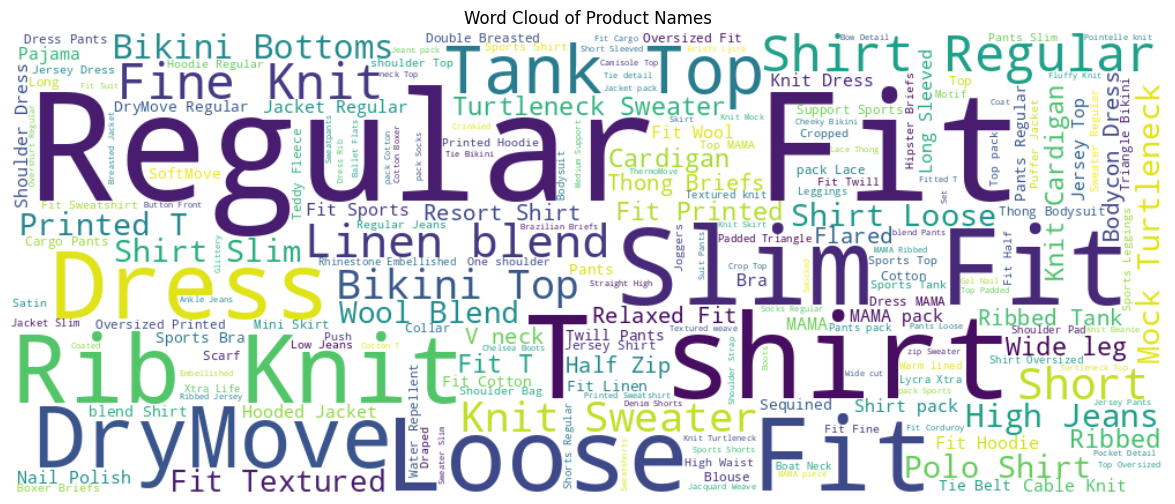

In [20]:
# 8. Word Cloud from Product Names
all_words = ' '.join(df['productName'].dropna().astype(str).values)
wordcloud = WordCloud(width=1000, height=400, background_color='white').generate(all_words)

plt.figure(figsize=(15, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Product Names')
plt.show()

## Thank you...pls upvote!!!